# Earth-Mars drainage calibration via network complexity

## Motivation

Earlier sweeps showed Earth `Dd_hull` stays structurally far above Mars at
every contributing-area threshold. The previous notebooks attacked that gap
by **(a)** sweeping thresholds and **(b)** trimming low Strahler orders, but
treated both knobs as fixed steps applied uniformly to every basin.

This notebook reframes the problem around **network complexity** measured by
the **Horton-Strahler maximum order** of each network. The idea is:

1. Compute the Strahler-complexity distribution for the 391 mapped Martian
   valley networks. Their flow direction is unknown, but the Horton-Strahler
   maximum of an unrooted tree is well-defined as the maximum over leaf
   rootings (textbook definition; we verify in the module tests).
2. Compute the same statistic for every Earth outlet basin across a range of
   contributing-area thresholds.
3. Quantify the **complexity gap**.
4. For each Earth outlet, apply a **per-outlet adaptive Strahler trim** that
   reduces its reranked max-Strahler to the Martian target. Compare the
   resulting `Dd_hull` distribution to Mars.
5. Visual gallery: Mars networks alongside Earth subnetworks at matched
   complexity.

All helpers live in `channel_heads.dd_calibration`:
- `mars_network_strahler` (new): per-network max Strahler for Mars.
- `run_practical_sweep` with `min_orders=(2, 3, 4, 5)` (param added): per-outlet
  Dd metrics for full + 4 trim variants, with `max_strahler_*` for each.
- `trim_to_min_order`: keeps only Strahler order >= k links.


## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch

from channel_heads.io.paths import EXAMPLE_DEMS, RESULTS_DIR
from channel_heads.basin_config import get_basin_config, LOCAL_TO_PAPER_BASIN
from channel_heads.dd_calibration import (
    MARS_DD_STATS,
    LOW_THRESHOLDS_KM2,
    STATUS_OK,
    mars_network_geometry,
    mars_network_strahler,
    mars_network_table,
    run_practical_sweep,
    collect_dd_hull_trim_for_dem,
    # calibration validation helpers (audit, coord matching, loss functions)
    validate_area_bin_grouping,
    augment_sweep_with_outlet_coords,
    match_outlets_by_coords,
    basin_to_hull_area_ratio,
    length_retention_penalty,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

OUT_DIR = RESULTS_DIR / "drainage_density_calibration" / "complexity_calibration"
OUT_DIR.mkdir(parents=True, exist_ok=True)
COMPLEXITY_CSV = OUT_DIR / "dd_master_sweep_complexity.csv"

BASINS = [k for k, v in EXAMPLE_DEMS.items() if v.exists()]
MIN_BASIN_PX, MAX_OUTLETS = 1000, 80
MIN_ORDERS = (2, 3, 4, 5)   # covers Earth max_strahler up to 6 (reranked -> 1)

C_MARS, C_EARTH, C_TRIM, C_HULL, C_BASIN = (
    "#c0504d", "#1f6fb4", "#2e8b57", "#d2691e", "#5a8f6b")

print(f"{len(BASINS)} Earth DEMs available")
print(f"Min orders for trim variants: {MIN_ORDERS}")

17 Earth DEMs available
Min orders for trim variants: (2, 3, 4, 5)


In [2]:
# Shared map-drawing helpers (compact version of the practical_thresholds helpers).
_BARS = np.array([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])

def _polylines_pts(lines):
    return np.vstack([np.asarray(p)[:, :2] for p in lines])

def _bounds(*arrays):
    pts = np.vstack([np.asarray(a).reshape(-1, 2) for a in arrays
                     if a is not None and len(np.asarray(a))])
    lo, hi = pts.min(0), pts.max(0)
    ctr = (lo + hi) / 2
    half = max((hi - lo).max() / 2, 1.0) * 1.12
    return ctr, half

def draw_panel(ax, *, segs=None, lines=None, hull_xy=None, boundary_xy=None,
               title="", center=None, half=None, fontsize=8):
    "One network map panel; coords -> km."
    geoms = []
    if segs is not None and len(segs):
        geoms.append(np.asarray(segs).reshape(-1, 2))
    if lines is not None and len(lines):
        geoms.append(_polylines_pts(lines))
    if boundary_xy is not None:
        geoms.append(boundary_xy)
    if center is None or half is None:
        center, half = _bounds(*geoms)
    def T(a):
        return (np.asarray(a) - center) / 1000.0
    if boundary_xy is not None:
        b = T(boundary_xy)
        ax.plot(b[:, 0], b[:, 1], "-", color=C_BASIN, lw=1.0)
    if segs is not None and len(segs):
        n = len(segs)
        lw = float(np.clip(30.0 / np.sqrt(max(n, 1)), 0.1, 0.8))
        ax.add_collection(LineCollection((np.asarray(segs) - center) / 1000.0,
                          colors=C_EARTH, lw=lw))
    if lines is not None:
        for p in lines:
            q = T(p)
            ax.plot(q[:, 0], q[:, 1], "-", color=C_MARS, lw=0.7)
    if hull_xy is not None:
        h = T(np.vstack([hull_xy, hull_xy[:1]]))
        ax.plot(h[:, 0], h[:, 1], "--", color=C_HULL, lw=1.2)
        ax.fill(h[:, 0], h[:, 1], color=C_HULL, alpha=0.07)
    hk = half / 1000.0
    ax.set_xlim(-hk, hk); ax.set_ylim(-hk, hk)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=fontsize)
    sb = _BARS[np.argmin(np.abs(_BARS - hk / 2))]
    x0, y0 = -hk * 0.92, -hk * 0.92
    ax.plot([x0, x0 + sb], [y0, y0], "k-", lw=2.0)
    ax.text(x0 + sb / 2, y0 + hk * 0.04, f"{sb:g} km",
            ha="center", va="bottom", fontsize=6)

## 1. Martian Strahler-complexity distribution

`mars_network_strahler()` builds an undirected graph from each network's
MultiLineString (snapping endpoints at mm precision) and computes the
Horton-Strahler max as `max(over leaf rootings)`. The result is invariant
to choice of outlet for a tree.


In [3]:
mstr = mars_network_strahler()
ok_m = mstr[mstr["status"] == STATUS_OK].copy()

print(f"Mars networks: {len(ok_m)} valid out of {len(mstr)}")
print(f"  cycles flagged (is_tree=False): {(~mstr.is_tree).sum()}")
print(f"  multi-component networks:      {(mstr.n_components > 1).sum()}")
print()
print("Per-network max Strahler:")
print(ok_m["max_strahler"].value_counts().sort_index().to_frame("n_networks"))
print()
print(ok_m[["max_strahler", "n_leaves", "length_km", "dd_hull"]].describe().round(3))

MARS_S_MED = int(ok_m["max_strahler"].median())
MARS_S_Q1, MARS_S_Q3 = ok_m["max_strahler"].quantile([.25, .75]).astype(int).tolist()
print(f"\nMars target: median max-Strahler = {MARS_S_MED}  (IQR {MARS_S_Q1}-{MARS_S_Q3})")

Mars networks: 391 valid out of 391
  cycles flagged (is_tree=False): 2
  multi-component networks:      0

Per-network max Strahler:
              n_networks
max_strahler            
2                     13
3                    338
4                     38
5                      2

       max_strahler  n_leaves  length_km  dd_hull
count      391.0000  391.0000   391.0000 391.0000
mean         3.0740    8.6730   171.1320   0.2420
std          0.3820    5.3830   172.7680   0.1190
min          2.0000    4.0000    28.4400   0.0170
25%          3.0000    5.0000    80.7550   0.1610
50%          3.0000    7.0000   122.4000   0.2240
75%          3.0000   10.0000   213.1350   0.2990
max          5.0000   37.0000  2313.3700   0.7250

Mars target: median max-Strahler = 3  (IQR 3-3)


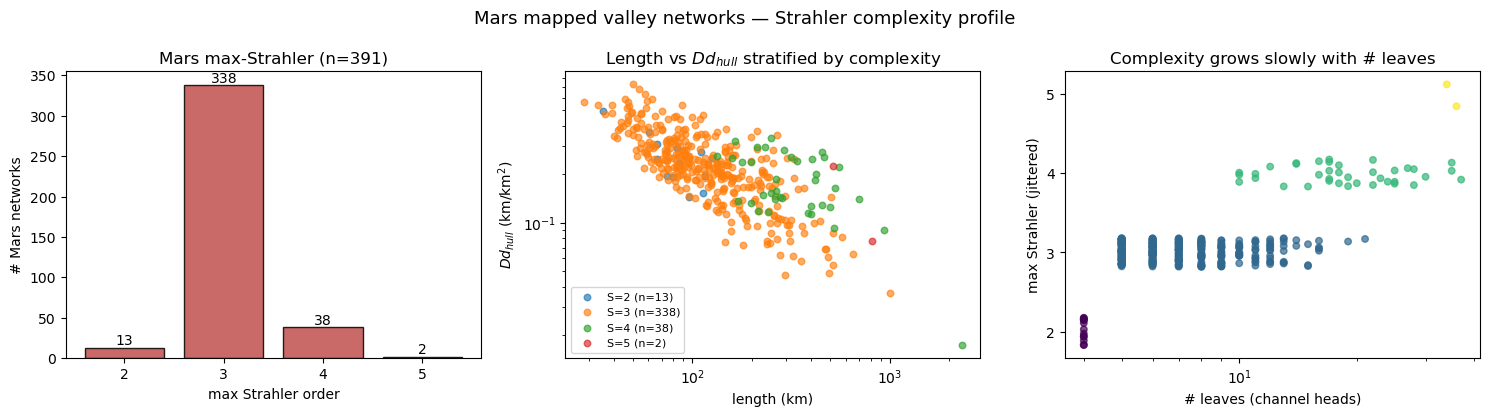

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) Mars Strahler histogram
ax = axes[0]
counts = ok_m["max_strahler"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=C_MARS, alpha=0.85, edgecolor="k")
for x, y in counts.items():
    ax.text(x, y + max(counts.values) * 0.01, f"{int(y)}",
            ha="center", fontsize=10)
ax.set_xlabel("max Strahler order"); ax.set_ylabel("# Mars networks")
ax.set_title(f"Mars max-Strahler (n={len(ok_m)})")
ax.set_xticks(sorted(ok_m["max_strahler"].unique()))

# (b) Length vs Dd_hull, colored by Strahler
ax = axes[1]
for s_val, grp in ok_m.groupby("max_strahler"):
    ax.scatter(grp["length_km"], grp["dd_hull"],
               label=f"S={int(s_val)} (n={len(grp)})", alpha=0.65, s=22)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("length (km)"); ax.set_ylabel(r"$Dd_{hull}$ (km/km$^2$)")
ax.set_title("Length vs $Dd_{hull}$ stratified by complexity")
ax.legend(fontsize=8, loc="lower left")

# (c) Strahler vs leaf count
ax = axes[2]
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.18, 0.18, len(ok_m))
ax.scatter(ok_m["n_leaves"], ok_m["max_strahler"] + jitter,
           c=ok_m["max_strahler"], cmap="viridis", alpha=0.7, s=22)
ax.set_xscale("log")
ax.set_xlabel("# leaves (channel heads)"); ax.set_ylabel("max Strahler (jittered)")
ax.set_title("Complexity grows slowly with # leaves")
ax.set_yticks(sorted(ok_m["max_strahler"].unique()))

fig.suptitle("Mars mapped valley networks — Strahler complexity profile",
             fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_mars_strahler_distribution.png", dpi=150)
plt.show()

## 2. Mars `Dd_hull` sanity check (kept compact)

In [5]:
mtbl = mars_network_table()
mok = mtbl.loc[mtbl["status"] == STATUS_OK, "dd_hull_km_km2"]
check = pd.DataFrame({
    "recomputed":   [len(mok), mok.median(), mok.quantile(.25), mok.quantile(.75)],
    "MARS_DD_STATS": [MARS_DD_STATS["n"], MARS_DD_STATS["median"],
                      MARS_DD_STATS["q1"], MARS_DD_STATS["q3"]],
}, index=["n", "median", "q1", "q3"]).round(4)
print(check)
assert abs(mok.median() - MARS_DD_STATS["median"]) < 1e-6
print("\nMars Dd_hull pipeline reproduces MARS_DD_STATS exactly.")

        recomputed  MARS_DD_STATS
n         391.0000       391.0000
median      0.2239         0.2239
q1          0.1612         0.1612
q3          0.2987         0.2987

Mars Dd_hull pipeline reproduces MARS_DD_STATS exactly.


## 3. Earth per-outlet Strahler across thresholds

`run_practical_sweep(min_orders=(2,3,4,5))` builds, for every outlet at every
threshold:
- the full network (`*_full` columns)
- four pruned variants: orders >= 2, 3, 4, 5 (`_trim`, `_ge3`, `_ge4`, `_ge5`)

`max_strahler_*` is recorded for each variant. Because TopoToolbox's
`streamorder("strahler")` recomputes from the subgraph's leaves, the trim
variant's max equals the **reranked** depth — i.e. trimming with min_order
*k* gives `max_strahler_ge{k} = max_strahler_full - (k - 1)` whenever the
trunk survives.

Cached to `dd_master_sweep_complexity.csv`. **First run is heavy** (rebuilds
StreamObjects across ten thresholds for every DEM) — expect tens of minutes.


In [6]:
master = run_practical_sweep(
    basins=BASINS,
    thresholds_km2=LOW_THRESHOLDS_KM2,
    cache_csv=COMPLEXITY_CSV,
    min_outlet_basin_pixels=MIN_BASIN_PX,
    max_outlets=MAX_OUTLETS,
    min_orders=MIN_ORDERS,
    verbose=True,
)
print(f"\nrows: {len(master)}  basins: {master.dem_name.nunique()}  "
      f"thresholds: {master.threshold_km2.nunique()}")

full = master[master["status_full"] == "ok"].copy()
print(f"valid full outlets: {len(full)}")

Loading cached sweep: /Users/guypi/Projects/channel-heads/data/results/drainage_density_calibration/complexity_calibration/dd_master_sweep_complexity.csv

rows: 5046  basins: 17  thresholds: 10
valid full outlets: 5038


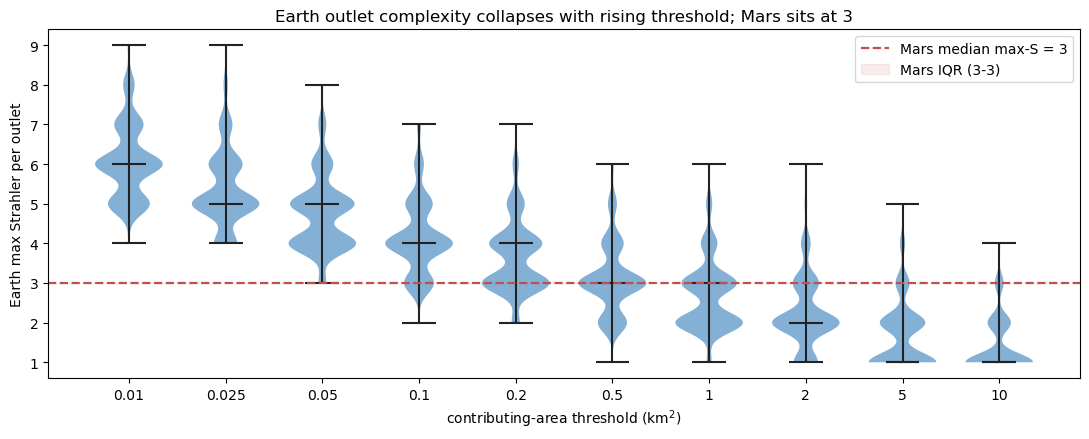

In [7]:
# Earth max-Strahler per outlet, faceted by threshold.
thresholds = sorted(full.threshold_km2.unique())
fig, ax = plt.subplots(figsize=(11, 4.5))

positions = np.arange(len(thresholds))
data = [full.loc[np.isclose(full.threshold_km2, t), "max_strahler_full"].dropna()
        for t in thresholds]
parts = ax.violinplot(data, positions=positions, showmedians=True, widths=0.7)
for body in parts['bodies']:
    body.set_facecolor(C_EARTH); body.set_alpha(0.55)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    if key in parts:
        parts[key].set_color("#222")

ax.axhline(MARS_S_MED, color=C_MARS, ls="--", lw=1.6,
           label=f"Mars median max-S = {MARS_S_MED}")
ax.axhspan(MARS_S_Q1, MARS_S_Q3, color=C_MARS, alpha=0.10,
           label=f"Mars IQR ({MARS_S_Q1}-{MARS_S_Q3})")
ax.set_xticks(positions)
ax.set_xticklabels([f"{t:g}" for t in thresholds])
ax.set_xlabel("contributing-area threshold (km$^2$)")
ax.set_ylabel("Earth max Strahler per outlet")
ax.set_title("Earth outlet complexity collapses with rising threshold; Mars sits at 3")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_earth_strahler_vs_threshold.png", dpi=150)
plt.show()

## 4. The complexity gap: Mars vs Earth per threshold

Normalised histograms make the distributional mismatch direct: at low
thresholds Earth outlets are dominated by max-Strahler 4-5 (vs Mars 3); the
distributions only begin to overlap at the practical-range upper end.


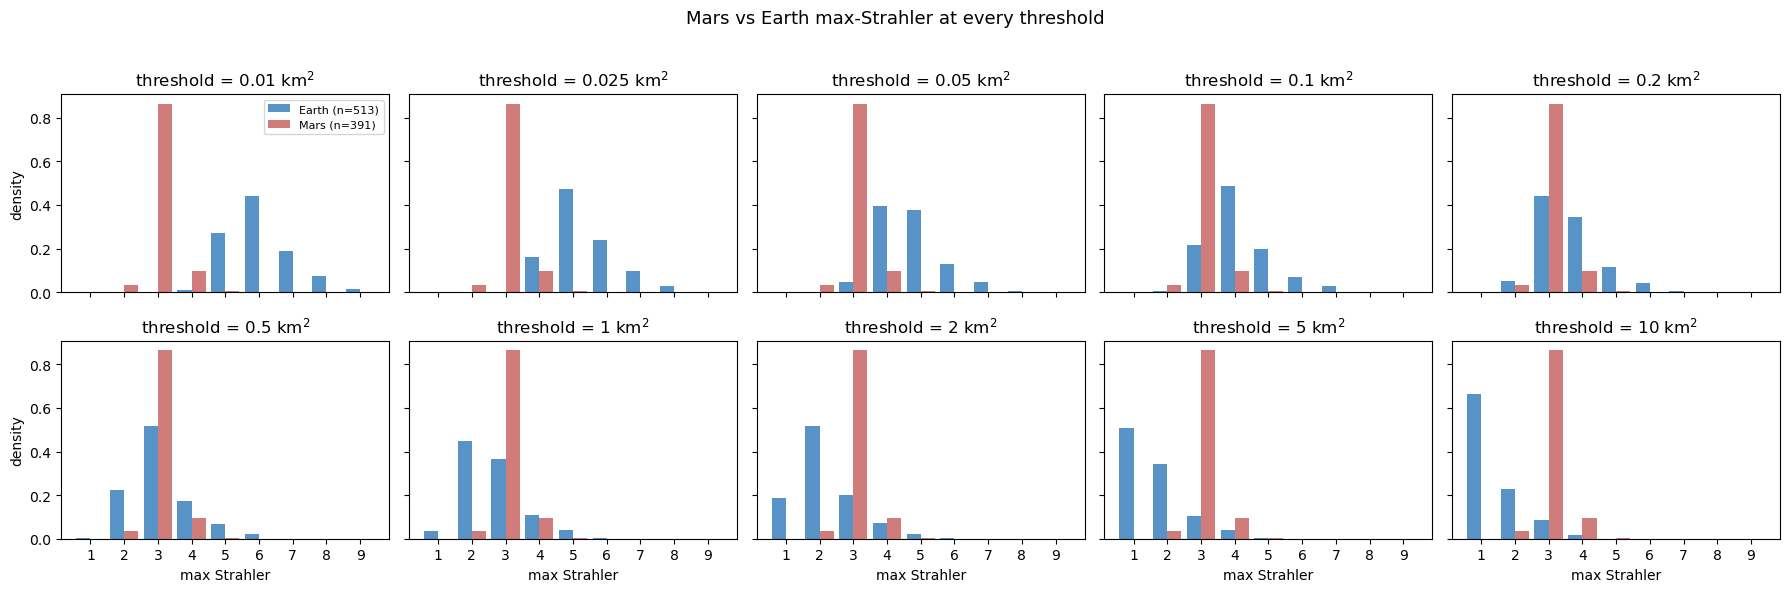

,threshold_km2,n_outlets,earth_S_median,earth_S_q3,mars_S_median,mars_S_q3,pct_outlets_match_mars
0,0.0100,513,6,7,3,3,0.0000
1,0.0200,513,5,6,3,3,0.0000
2,0.0500,513,5,5,3,3,4.4800
3,0.1000,513,4,5,3,3,21.4400
4,0.2000,513,4,4,3,3,43.8600
5,0.5000,513,3,4,3,3,51.6600
6,1.0000,513,3,3,3,3,36.6500
7,2.0000,513,2,3,3,3,20.0800
8,5.0000,512,1,2,3,3,10.5500
9,10.0000,422,1,2,3,3,8.5300


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True, sharex=True)
all_S = np.arange(1, max(int(full.max_strahler_full.max() or 0),
                          int(ok_m.max_strahler.max())) + 1)
bins = np.arange(all_S.min() - 0.5, all_S.max() + 1.5)

# Mars histogram normalized
mars_hist, _ = np.histogram(ok_m["max_strahler"], bins=bins, density=True)

for ax, t in zip(axes.flat, thresholds):
    earth = full.loc[np.isclose(full.threshold_km2, t), "max_strahler_full"].dropna()
    earth_hist, _ = np.histogram(earth, bins=bins, density=True)
    width = 0.42
    centers = bins[:-1] + 0.5
    ax.bar(centers - width/2, earth_hist, width=width, color=C_EARTH,
           alpha=0.75, label=f"Earth (n={len(earth)})")
    ax.bar(centers + width/2, mars_hist, width=width, color=C_MARS,
           alpha=0.75, label=f"Mars (n={len(ok_m)})")
    ax.set_title(f"threshold = {t:g} km$^2$")
    ax.set_xticks(all_S)
for ax in axes[-1, :]:
    ax.set_xlabel("max Strahler")
for ax in axes[:, 0]:
    ax.set_ylabel("density")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Mars vs Earth max-Strahler at every threshold", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT_DIR / "fig_mars_vs_earth_strahler_per_threshold.png", dpi=150)
plt.show()

# Summary table.
rows = []
for t in thresholds:
    e = full.loc[np.isclose(full.threshold_km2, t), "max_strahler_full"].dropna()
    rows.append(dict(
        threshold_km2=t, n_outlets=len(e),
        earth_S_median=int(e.median()) if len(e) else np.nan,
        earth_S_q3=int(e.quantile(.75)) if len(e) else np.nan,
        mars_S_median=MARS_S_MED, mars_S_q3=MARS_S_Q3,
        pct_outlets_match_mars=100 * (e == MARS_S_MED).mean() if len(e) else np.nan,
    ))
gap_tbl = pd.DataFrame(rows).round(2)
display(gap_tbl)
gap_tbl.to_csv(OUT_DIR / "earth_vs_mars_strahler_summary.csv", index=False)

## 5. Per-outlet trim to match Martian complexity

For an Earth outlet with full max-Strahler `M`, trimming with `min_order = k`
yields a subnetwork whose **reranked** max equals `M - k + 1` (the trunk
keeps its position; lower-order streams are removed and `streamorder` is
recomputed from the new leaves).

To reduce to Martian target `T = MARS_S_MED`, choose
`k = M - T + 1` per outlet (clamped to >= 1, so basins already at or below
the target are unchanged). We pick the matching variant column from the
sweep (`full` / `trim` / `ge3` / `ge4` / `ge5`).


In [9]:
TARGET = MARS_S_MED  # Martian median max-Strahler
SUFFIXES = {1: "full", 2: "trim", 3: "ge3", 4: "ge4", 5: "ge5"}

# Per outlet, pick the trim variant whose reranked max-Strahler matches
# TARGET; fall back to the deepest variant we computed if more trimming is
# needed than the sweep covers.
def pick_matched_variant(row, target=TARGET):
    full_max = row["max_strahler_full"]
    if not np.isfinite(full_max) or full_max == 0:
        return (None, np.nan)
    k = max(1, int(full_max - target + 1))
    if k not in SUFFIXES:
        k = max(SUFFIXES.keys())
    sfx = SUFFIXES[k]
    return (sfx, k)


matched_rows = []
for _, r in full.iterrows():
    sfx, k = pick_matched_variant(r)
    if sfx is None:
        continue
    matched_rows.append(dict(
        basin_id=r.basin_id, dem_name=r.dem_name,
        outlet_node=int(r.outlet_node), threshold_km2=r.threshold_km2,
        full_max_strahler=int(r.max_strahler_full),
        applied_min_order=int(k),
        matched_variant=sfx,
        matched_max_strahler=r.get(f"max_strahler_{sfx}", np.nan),
        matched_dd_hull=r.get(f"dd_hull_{sfx}", np.nan),
        matched_dd_true=r.get(f"dd_true_{sfx}", np.nan),
        matched_length_km=r.get(f"length_km_{sfx}", np.nan),
        matched_hull_km2=r.get(f"hull_area_km2_{sfx}", np.nan),
        matched_status=r.get(f"status_{sfx}", ""),
        full_dd_hull=r.dd_hull_full, full_dd_true=r.dd_true_full,
    ))
matched = pd.DataFrame(matched_rows)
matched.to_csv(OUT_DIR / "earth_strahler_matched_to_mars.csv", index=False)
print(f"{len(matched)} matched-outlet rows (all thresholds)")
print()
print("Distribution of applied min_order:")
print(matched["applied_min_order"].value_counts().sort_index())
print()
print("Survival of the matched variant (status):")
print(matched["matched_status"].value_counts())

5038 matched-outlet rows (all thresholds)

Distribution of applied min_order:
applied_min_order
1    2570
2     929
3     804
4     483
5     252
Name: count, dtype: int64

Survival of the matched variant (status):
matched_status
ok    5038
Name: count, dtype: int64


survived matching: 5038 / 5038 (100.0%)


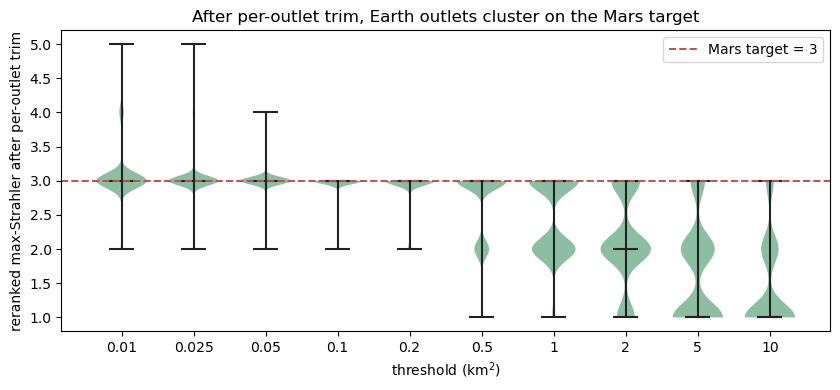

In [10]:
# Reranked max-Strahler after per-outlet matching, vs Mars target.
ok_m_match = matched[matched["matched_status"] == "ok"].copy()
print(f"survived matching: {len(ok_m_match)} / {len(matched)} "
      f"({100*len(ok_m_match)/max(len(matched),1):.1f}%)")

fig, ax = plt.subplots(figsize=(8.5, 4))
positions = np.arange(len(thresholds))
data = [ok_m_match.loc[np.isclose(ok_m_match.threshold_km2, t),
                       "matched_max_strahler"].dropna()
        for t in thresholds]
parts = ax.violinplot(data, positions=positions, showmedians=True, widths=0.7)
for body in parts['bodies']:
    body.set_facecolor(C_TRIM); body.set_alpha(0.55)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    if key in parts:
        parts[key].set_color("#222")

ax.axhline(TARGET, color=C_MARS, ls="--", lw=1.4,
           label=f"Mars target = {TARGET}")
ax.set_xticks(positions)
ax.set_xticklabels([f"{t:g}" for t in thresholds])
ax.set_xlabel("threshold (km$^2$)")
ax.set_ylabel("reranked max-Strahler after per-outlet trim")
ax.set_title("After per-outlet trim, Earth outlets cluster on the Mars target")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_earth_strahler_after_match.png", dpi=150)
plt.show()

## 6. Does complexity matching close the `Dd_hull` gap?

For each surviving matched-Earth outlet, the trimmed network's `Dd_hull` is
compared to Mars. We expect a smaller gap than the full-network case at the
same threshold; whether the residual gap collapses depends on whether the
hull-area side or the length side drives it.


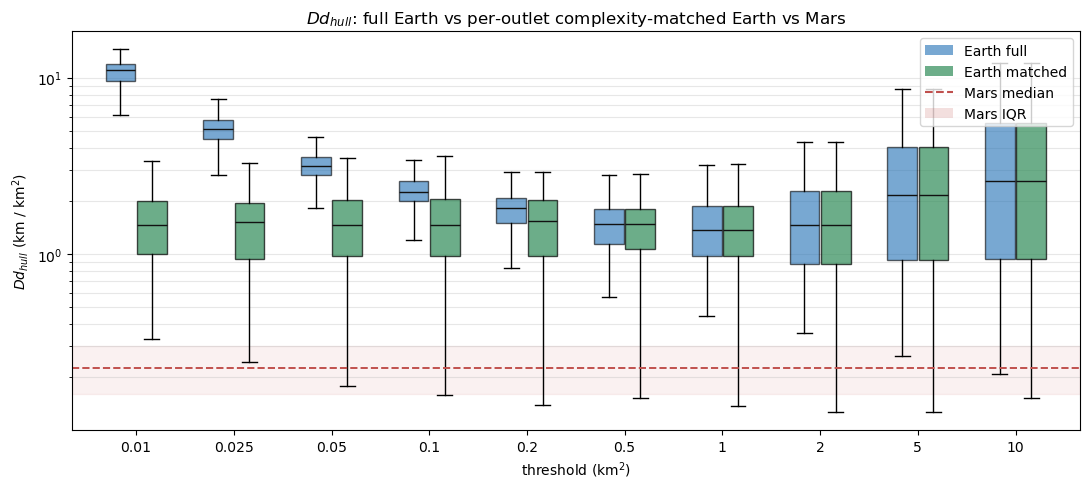

,threshold_km2,n_full,full_dd_med,n_match,match_dd_med,match_vs_mars_x
0,0.0100,513,11.1060,513,1.4570,6.5080
1,0.0250,513,5.1070,513,1.5080,6.7370
2,0.0500,513,3.1460,513,1.4670,6.5520
3,0.1000,513,2.2520,513,1.4620,6.5310
4,0.2000,513,1.8200,513,1.5380,6.8680
5,0.5000,513,1.4770,513,1.4680,6.5570
6,1.0000,513,1.3650,513,1.3650,6.0990
7,2.0000,513,1.4660,513,1.4660,6.5480
8,5.0000,512,2.1470,512,2.1470,9.5920
9,10.0000,422,2.5990,422,2.5990,11.6090


In [11]:
# Box-plot per threshold: full vs matched vs Mars reference.
fig, ax = plt.subplots(figsize=(11, 5))
positions = np.arange(len(thresholds))
w = 0.32

# Full
full_data = [full.loc[np.isclose(full.threshold_km2, t), "dd_hull_full"].dropna()
             for t in thresholds]
# Matched (per-outlet trim)
match_data = [ok_m_match.loc[np.isclose(ok_m_match.threshold_km2, t),
                              "matched_dd_hull"].dropna()
              for t in thresholds]
bp1 = ax.boxplot(full_data, positions=positions - w/2, widths=w*0.95,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor=C_EARTH, alpha=0.6),
                  medianprops=dict(color="#111"))
bp2 = ax.boxplot(match_data, positions=positions + w/2, widths=w*0.95,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor=C_TRIM, alpha=0.7),
                  medianprops=dict(color="#111"))

ax.axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.4,
           label=f"Mars median Dd_hull = {MARS_DD_STATS['median']:.3f}")
ax.axhspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"],
           color=C_MARS, alpha=0.08, label="Mars IQR")
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels([f"{t:g}" for t in thresholds])
ax.set_xlabel("threshold (km$^2$)")
ax.set_ylabel(r"$Dd_{hull}$ (km / km$^2$)")
ax.set_title("$Dd_{hull}$: full Earth vs per-outlet complexity-matched Earth vs Mars")
ax.legend(handles=[Patch(facecolor=C_EARTH, alpha=0.6, label="Earth full"),
                    Patch(facecolor=C_TRIM, alpha=0.7, label="Earth matched"),
                    plt.Line2D([0], [0], color=C_MARS, ls="--", label="Mars median"),
                    Patch(facecolor=C_MARS, alpha=0.18, label="Mars IQR")],
           loc="upper right")
ax.grid(True, which="both", axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_dd_hull_matched_vs_full_vs_mars.png", dpi=150)
plt.show()

# Numeric summary.
rows = []
for t in thresholds:
    e_full = full.loc[np.isclose(full.threshold_km2, t), "dd_hull_full"].dropna()
    e_match = ok_m_match.loc[np.isclose(ok_m_match.threshold_km2, t),
                              "matched_dd_hull"].dropna()
    rows.append(dict(
        threshold_km2=t,
        n_full=len(e_full), full_dd_med=e_full.median(),
        n_match=len(e_match), match_dd_med=e_match.median(),
        match_vs_mars_x=(e_match.median() / MARS_DD_STATS["median"]
                         if len(e_match) else np.nan),
    ))
dd_tbl = pd.DataFrame(rows).round(3)
display(dd_tbl)
dd_tbl.to_csv(OUT_DIR / "dd_hull_match_vs_mars_summary.csv", index=False)

## 7. Pruning maps: 1st- and 2nd-order trim at different thresholds

Visual inspection of what each pruning step removes - restored from the
previous practical-thresholds notebook. For a single selected basin
(threshold-stable seed outlet via `single_basin_threshold_geometry`), we
build the full network plus the `\ge 2` (no 1st-order) and `\ge 3`
(no 1st + 2nd order) variants at several thresholds. Each panel reports
its own `Dd_hull` so the geometric and numerical effect of the trim is
side-by-side.


In [12]:
# === EDITABLE PARAMETERS =============================================
PRUNE_MAP_BASIN = "sakhalin"
PRUNE_MAP_OUTLET_RANK = 0
PRUNE_MAP_THRESHOLDS = [0.1, 0.5, 1.0, 5.0]
# =====================================================================

from channel_heads.dd_calibration import single_basin_threshold_geometry
if PRUNE_MAP_BASIN not in BASINS:
    PRUNE_MAP_BASIN = BASINS[0]
cfg = get_basin_config(LOCAL_TO_PAPER_BASIN.get(PRUNE_MAP_BASIN, PRUNE_MAP_BASIN))
sel = single_basin_threshold_geometry(
    dem_path=EXAMPLE_DEMS[PRUNE_MAP_BASIN],
    basin_name=PRUNE_MAP_BASIN,
    thresholds_km2=PRUNE_MAP_THRESHOLDS,
    z_th=cfg["z_th"],
    lat_deg=cfg["lat"],
    outlet_rank=PRUNE_MAP_OUTLET_RANK,
    with_pruning=True,
)
sel = [s for s in sel if s["variants"]["full"]["status"] == "ok"]
print(f"{PRUNE_MAP_BASIN} rank {PRUNE_MAP_OUTLET_RANK} "
      f"(seed node {sel[0]['seed_outlet_node']}) - "
      f"{len(sel)} thresholds with usable geometry")

sakhalin rank 0 (seed node 13675) - 4 thresholds with usable geometry


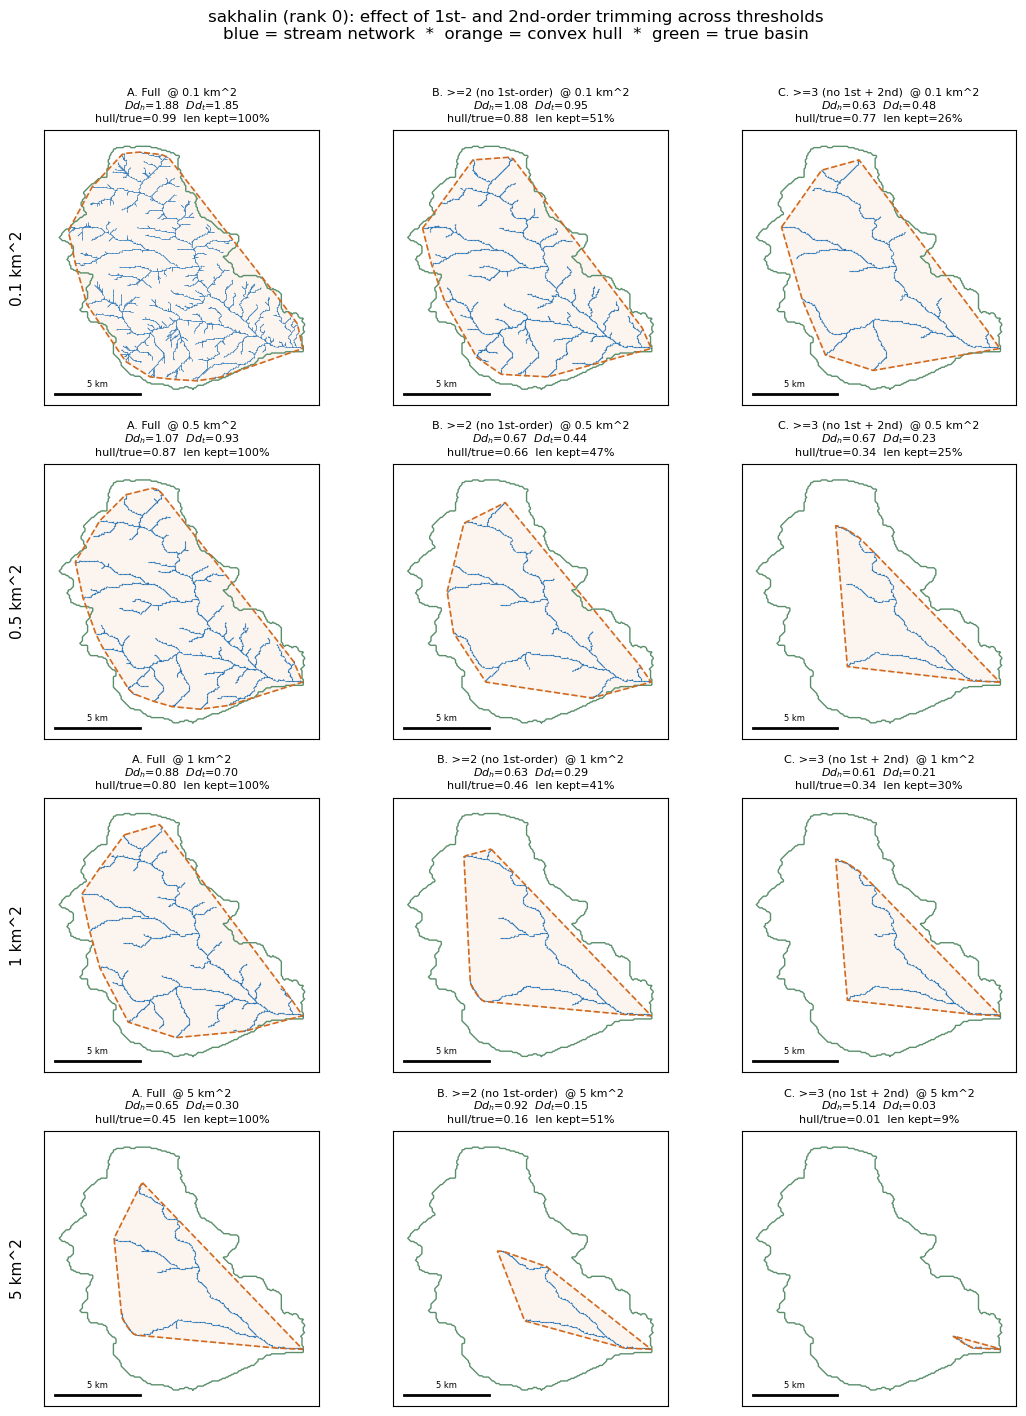

,threshold_km2,variant,dd_hull,dd_true,hull_true_ratio,max_strahler,pct_length_retained,status
0,0.1000,full,1.8760,1.8540,0.9880,5,100.0000,ok
1,0.1000,ge2,1.0800,0.9500,0.8800,4,51.2610,ok
2,0.1000,ge3,0.6290,0.4830,0.7680,3,26.0660,ok
3,0.5000,full,1.0710,0.9330,0.8710,4,100.0000,ok
4,0.5000,ge2,0.6660,0.4410,0.6620,3,47.2130,ok
5,0.5000,ge3,0.6660,0.2290,0.3440,2,24.5580,ok
6,1.0000,full,0.8800,0.7040,0.8000,4,100.0000,ok
7,1.0000,ge2,0.6250,0.2900,0.4640,3,41.2200,ok
8,1.0000,ge3,0.6130,0.2110,0.3440,2,29.9800,ok
9,5.0000,full,0.6540,0.2960,0.4530,3,100.0000,ok


In [13]:
# Grid: rows = thresholds, columns = full / >=2 (no 1st) / >=3 (no 1st+2nd)
n_thr = len(sel)
fig, axes = plt.subplots(n_thr, 3, figsize=(11, 3.6 * n_thr), squeeze=False)
ctr, half = _bounds(sel[0]["variants"]["full"]["stream_seg"],
                    sel[0]["basin_boundary_xy"])

variant_keys = [("full", "A. Full"),
                ("ge2",  "B. >=2 (no 1st-order)"),
                ("ge3",  "C. >=3 (no 1st + 2nd)")]

for ri, s in enumerate(sel):
    bb = s["basin_boundary_xy"]
    for ci, (vk, lab) in enumerate(variant_keys):
        v = s["variants"].get(vk)
        ax = axes[ri, ci]
        if v is None or v.get("status") != "ok":
            ax.axis("off"); continue
        hr = v["hull_area_km2"] / s["basin_area_km2"]
        pct = v["pct_length_retained"] if vk != "full" else 100.0
        draw_panel(ax,
                   segs=v["stream_seg"],
                   hull_xy=v["hull_xy"],
                   boundary_xy=bb,
                   center=ctr, half=half,
                   title=f"{lab}  @ {s['threshold_km2']:g} km^2\n"
                         f"$Dd_h$={v['dd_hull']:.2f}  $Dd_t$={v['dd_true']:.2f}\n"
                         f"hull/true={hr:.2f}  len kept={pct:.0f}%")
    axes[ri, 0].set_ylabel(f"{s['threshold_km2']:g} km^2",
                            fontsize=11, rotation=90, labelpad=14)

fig.suptitle(f"{PRUNE_MAP_BASIN} (rank {PRUNE_MAP_OUTLET_RANK}): "
             f"effect of 1st- and 2nd-order trimming across thresholds\n"
             f"blue = stream network  *  orange = convex hull  *  green = true basin",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / f"fig_pruning_maps_{PRUNE_MAP_BASIN}.png", dpi=140)
plt.show()

# Quantitative summary across the thresholds we plotted.
summ_rows = []
for s in sel:
    for vk in ("full", "ge2", "ge3"):
        v = s["variants"].get(vk)
        if v is None: continue
        summ_rows.append({
            "threshold_km2": s["threshold_km2"], "variant": vk,
            "dd_hull": v["dd_hull"], "dd_true": v["dd_true"],
            "hull_true_ratio": v["hull_area_km2"] / s["basin_area_km2"],
            "max_strahler": v["max_strahler"],
            "pct_length_retained": v.get("pct_length_retained", 100.0),
            "status": v["status"],
        })
prune_tbl = pd.DataFrame(summ_rows).round(3)
display(prune_tbl)
prune_tbl.to_csv(OUT_DIR / f"pruning_maps_{PRUNE_MAP_BASIN}.csv", index=False)

## 8. Per-outlet calibration (not Dd_hull chasing)

> **Calibration vs evaluation.** Optimising Earth `Dd_hull` directly toward
> Mars `Dd_hull` is circular - it forces the comparison metric onto the
> result. The defensible workflow is to *calibrate* terrestrial networks to
> match Mars in **complexity and geometric representativeness**, and *only
> then* report `Dd_hull` (and related metrics) as evaluation outcomes.

This section's optimiser uses three **calibration** losses only:

* **Complexity loss** $L_S = \lvert S^* - S_{Mars}\rvert / S_{Mars}$
  pulls reranked max-Strahler $S^* = M - (k-1)$ toward $S_{Mars} = 3$.
* **Hull-vs-basin loss** $L_B = \lvert \mathrm{basin\_to\_hull\_area\_ratio} - 1\rvert$
  where $\mathrm{basin\_to\_hull\_area\_ratio} = Dd_h / Dd_t = A_{basin}/A_{hull}$.
  $= 1$ means the convex hull tracks the true catchment exactly.
* **Length-retention penalty** $L_R$ (quadratic) discourages over-pruning
  below `MIN_RETAINED_PCT`% of the original stream length.

**Notably absent**: any term that pulls $Dd_h$ toward Mars. The
post-optimization section reports $Dd_h$ as an honest *outcome*.

Cross-threshold outlet identity is established via **DEM-grid coordinates**
when present (added to the sweep cache by the outlet-coord patch). If the
cache predates that patch the validator's warnings are shown and the
optimiser falls back to area-bin grouping.


In [14]:
# === Cross-threshold outlet matching + audit =========================
AREA_BIN_KM2 = 0.1
COORD_TOL_PX = 2

audit = validate_area_bin_grouping(master,
                                   area_bin_km2=AREA_BIN_KM2,
                                   coord_tol_px=COORD_TOL_PX)
print(f"area_bin grouping audit ({len(audit['warnings'])} warnings):")
for w in audit["warnings"]:
    print("  - " + w)
print()
print("Per-DEM merge rate (top 8):")
display(audit["summary"].head(8))

# If the cache predates the outlet-coord patch, run the augmenter to backfill
# outlet_row / outlet_col so cross-threshold matching is exact. The
# augmenter rebuilds StreamObjects but skips per-outlet variants, so it is
# ~3-5x faster than re-running the full sweep.
RUN_AUGMENT = True   # set False to skip and stay on area-bin grouping
if RUN_AUGMENT and "outlet_row" not in master.columns:
    print("\nBackfilling outlet coordinates into the cache (5-15 min)...")
    master = augment_sweep_with_outlet_coords(master, out_csv=COMPLEXITY_CSV)
    audit = validate_area_bin_grouping(master,
                                       area_bin_km2=AREA_BIN_KM2,
                                       coord_tol_px=COORD_TOL_PX)
    print("post-augment warnings:")
    for w in audit["warnings"]:
        print("  - " + w)

if "outlet_row" in master.columns:
    master = match_outlets_by_coords(master, coord_tol_px=COORD_TOL_PX)
    OUTLET_KEY = "outlet_cluster"
    n_clusters = master["outlet_cluster"].nunique()
    print(f"\nCoord matching: {n_clusters} unique outlet clusters across DEMs.")
else:
    master["area_bin"] = (master["basin_area_km2"] / AREA_BIN_KM2).round().astype(int)
    master["outlet_cluster"] = (master["dem_name"] + "_b"
                                 + master["area_bin"].astype(str))
    OUTLET_KEY = "outlet_cluster"
    print("\nFallback to area-bin grouping; warnings above apply.")

area_bin grouping audit (1 warnings):
  - 291 (dem, area_bin, threshold) groups merge >=2 distinct outlets -- area-bin grouping is unsafe at area_bin_km2=0.1. Consider outlet-coordinate matching.

Per-DEM merge rate (top 8):


,dem_name,n_outlets,n_groups,n_merge_groups,pct_merge_groups
0,panamint,148,129,19,14.7000
1,humboldt,140,135,19,14.1000
2,toano,160,163,18,11.0000
3,sierranevadaspain,220,207,20,9.7000
4,vallefertil,425,391,38,9.7000
5,finisterre,795,729,69,9.5000
6,sierramadre,787,749,50,6.7000
7,calnalpine,145,139,9,6.5000



Coord matching: 509 unique outlet clusters across DEMs.


In [15]:
# === EDITABLE WEIGHTS (CALIBRATION ONLY) =============================
W_COMPLEXITY     = 1.0    # pull reranked max-Strahler S* -> MARS_S_MED
W_HULL_BASIN     = 1.0    # pull basin_to_hull_area_ratio -> 1
W_RETENTION      = 1.0    # penalty if retained-length pct < MIN_RETAINED_PCT
MIN_RETAINED_PCT = 30.0   # below this the candidate is strongly penalised
# Note: no Dd_hull-toward-Mars term. Dd_hull is an evaluation outcome.
# =====================================================================

VARIANT_K = {"full": 1, "trim": 2, "ge3": 3, "ge4": 4, "ge5": 5}


def calibration_loss(row, sfx,
                     w_S=W_COMPLEXITY, w_B=W_HULL_BASIN, w_R=W_RETENTION,
                     min_pct=MIN_RETAINED_PCT):
    if row.get(f"status_{sfx}", "") != "ok":
        return None
    dh = row.get(f"dd_hull_{sfx}", np.nan)
    dt = row.get(f"dd_true_{sfx}", np.nan)
    ms = row.get(f"max_strahler_{sfx}", np.nan)
    pct = (row.get(f"pct_length_{sfx}", 100.0) if sfx != "full" else 100.0)
    if not (np.isfinite(dh) and np.isfinite(dt) and dt > 0 and np.isfinite(ms)):
        return None
    L_S = abs(ms - MARS_S_MED) / max(MARS_S_MED, 1)
    L_B = abs(basin_to_hull_area_ratio(dh, dt) - 1.0)
    L_R = length_retention_penalty(pct, min_retained_pct=min_pct)
    L = w_S * L_S + w_B * L_B + w_R * L_R
    return dict(L_S=L_S, L_B=L_B, L_R=L_R, L=L, pct_length=float(pct))


def optimize_per_outlet(df, **weights):
    df = df[df["status_full"] == "ok"].copy()
    picks = []
    for (dem, cluster), grp in df.groupby(["dem_name", OUTLET_KEY]):
        candidates = []
        for _, row in grp.iterrows():
            for sfx, k in VARIANT_K.items():
                loss = calibration_loss(row, sfx, **weights)
                if loss is None:
                    continue
                candidates.append({
                    "dem_name": dem, "outlet_cluster": cluster,
                    "outlet_node_at_threshold": int(row["outlet_node"]),
                    "threshold_km2": row["threshold_km2"],
                    "variant": sfx, "min_order": k,
                    "post_max_strahler": int(row[f"max_strahler_{sfx}"]),
                    "full_max_strahler": int(row["max_strahler_full"]),
                    "dd_hull": float(row[f"dd_hull_{sfx}"]),
                    "dd_true": float(row[f"dd_true_{sfx}"]),
                    "basin_to_hull_area_ratio": float(basin_to_hull_area_ratio(
                        row[f"dd_hull_{sfx}"], row[f"dd_true_{sfx}"])),
                    "length_km": row.get(f"length_km_{sfx}", np.nan),
                    "hull_area_km2": row.get(f"hull_area_km2_{sfx}", np.nan),
                    "basin_area_km2": float(row["basin_area_km2"]),
                    **loss,
                })
        if not candidates:
            continue
        candidates.sort(key=lambda c: c["L"])
        picks.append(candidates[0])
    return pd.DataFrame(picks)


opt = optimize_per_outlet(master)
opt.to_csv(OUT_DIR / "per_outlet_optimization.csv", index=False)
print(f"optimized: {len(opt)} outlet clusters")
print()
print("Chosen threshold distribution:")
print(opt["threshold_km2"].value_counts().sort_index())
print()
print("Chosen variant distribution:")
print(opt["variant"].value_counts())
print()
print("Loss components (medians) -- calibration-only:")
print(opt[["L_S", "L_B", "L_R", "L"]].median().round(3).to_frame("median"))

optimized: 509 outlet clusters

Chosen threshold distribution:
threshold_km2
0.0100      36
0.0250      84
0.0500      92
0.1000     107
0.2000     104
0.5000      38
1.0000      25
2.0000      13
5.0000       7
10.0000      3
Name: count, dtype: int64

Chosen variant distribution:
variant
trim    247
full    221
ge3      41
Name: count, dtype: int64

Loss components (medians) -- calibration-only:
     median
L_S  0.0000
L_B  0.1950
L_R  0.0000
L    0.3010


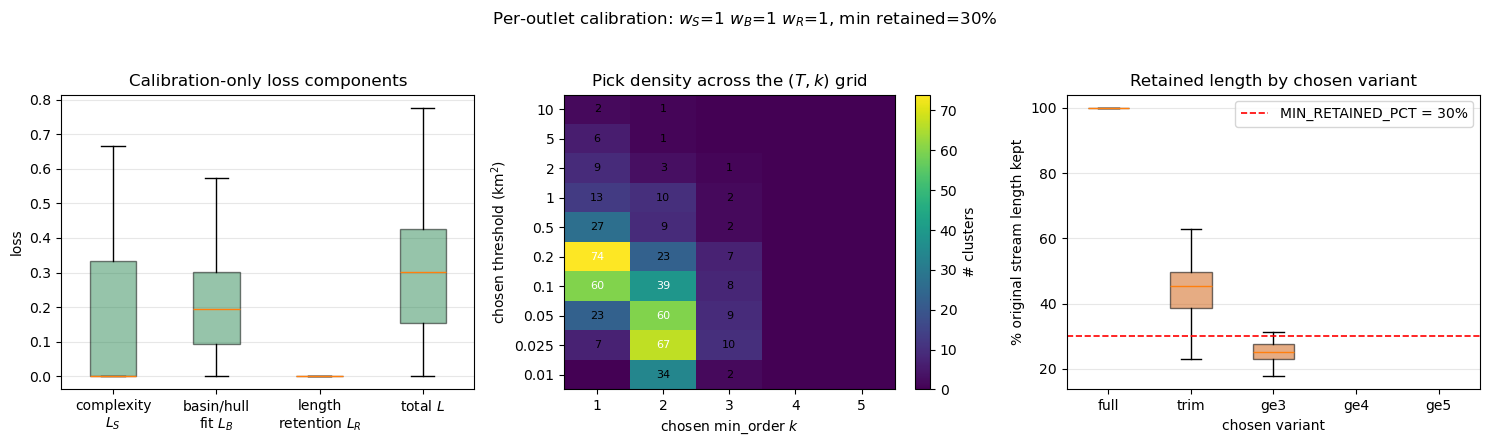

In [16]:
# Diagnostics: loss components, (T, k) pick density, length retention.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Loss-component boxplot (calibration-only).
ax = axes[0]
ax.boxplot([opt["L_S"], opt["L_B"], opt["L_R"], opt["L"]],
           tick_labels=["complexity\n$L_S$",
                        "basin/hull\nfit $L_B$",
                        "length\nretention $L_R$",
                        "total $L$"],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=C_TRIM, alpha=0.5))
ax.set_ylabel("loss")
ax.set_title("Calibration-only loss components")
ax.grid(True, axis="y", alpha=0.3)

# (b) (threshold, min_order) pick density.
ax = axes[1]
pivot = (opt.groupby(["threshold_km2", "min_order"]).size()
         .unstack(fill_value=0))
pivot = pivot.reindex(index=sorted(thresholds),
                      columns=sorted(VARIANT_K.values()), fill_value=0)
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels([f"{t:g}" for t in pivot.index])
ax.set_xlabel("chosen min_order $k$"); ax.set_ylabel("chosen threshold (km$^2$)")
ax.set_title("Pick density across the $(T, k)$ grid")
for (i, j), v in np.ndenumerate(pivot.values):
    if v > 0:
        ax.text(j, i, int(v), ha="center", va="center",
                color="white" if v > pivot.values.max() / 2 else "black",
                fontsize=8)
plt.colorbar(im, ax=ax, label="# clusters")

# (c) Retained-length distribution by chosen variant.
ax = axes[2]
order = ["full", "trim", "ge3", "ge4", "ge5"]
data = [opt.loc[opt.variant == v, "pct_length"].dropna() for v in order]
ax.boxplot(data, tick_labels=order, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=C_HULL, alpha=0.55))
ax.axhline(MIN_RETAINED_PCT, color="red", ls="--", lw=1.2,
           label=f"MIN_RETAINED_PCT = {MIN_RETAINED_PCT:g}%")
ax.set_ylabel("% original stream length kept")
ax.set_xlabel("chosen variant")
ax.set_title("Retained length by chosen variant")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Per-outlet calibration: "
             f"$w_S$={W_COMPLEXITY:g} $w_B$={W_HULL_BASIN:g} $w_R$={W_RETENTION:g}, "
             f"min retained={MIN_RETAINED_PCT:g}%",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "fig_optimization_diagnostics.png", dpi=150)
plt.show()

## 9. Evaluation phase: $Dd_{hull}$ AFTER calibration

`Dd_hull` was deliberately **excluded** from the optimisation objective. The
question now is: *given* the per-outlet calibration picks, where does the
resulting Earth distribution sit relative to Mars? Overlap (or its absence)
is an honest outcome, not a target. Three panels compare:

1. **Strahler distribution** -- by construction the optimiser pushes Earth
   to $S = 3$; we verify and quantify the overlap with Mars.
2. **$Dd_{hull}$ distribution** -- the evaluation metric.
3. **`basin_to_hull_area_ratio`** -- whether the calibrated hull actually
   tracks the true basin ($\approx 1$).


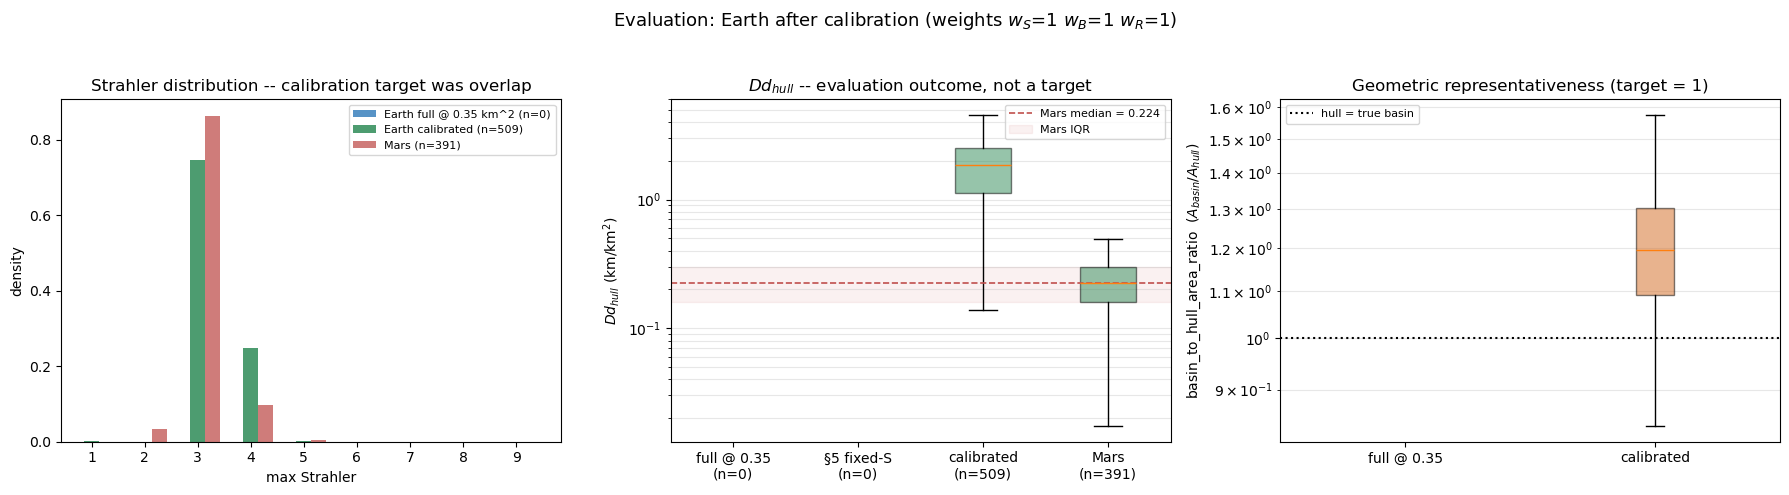

,Earth full @ med-T,Earth calibrated,Mars
metric,,,
n,0.0000,509.0000,391.0000
Strahler median,NaN,3.0000,3.0000
Dd_hull median,NaN,1.8400,0.2240
Dd_hull / Mars,NaN,8.2200,1.0000
basin/hull ratio median,NaN,1.1950,NaN


In [17]:
# Build baselines: full at the median Earth threshold, and the §5 single-target match.
BASELINE_THRESHOLD = float(np.median(thresholds))
full_base = full[np.isclose(full.threshold_km2, BASELINE_THRESHOLD)].copy()
full_base["basin_to_hull_area_ratio"] = basin_to_hull_area_ratio(
    full_base["dd_hull_full"].values, full_base["dd_true_full"].values)
match_base = ok_m_match[np.isclose(ok_m_match.threshold_km2, BASELINE_THRESHOLD)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Strahler distributions
ax = axes[0]
all_S = np.arange(1, max(int(full.max_strahler_full.max() or 0),
                          int(ok_m.max_strahler.max())) + 1)
bins = np.arange(all_S.min() - 0.5, all_S.max() + 1.5)
width = 0.28
centers = bins[:-1] + 0.5

def _norm_hist(series):
    h, _ = np.histogram(series.dropna(), bins=bins, density=True)
    return h

ax.bar(centers - width, _norm_hist(full_base["max_strahler_full"]),
       width=width, color=C_EARTH, alpha=0.75,
       label=f"Earth full @ {BASELINE_THRESHOLD:g} km^2 (n={len(full_base)})")
ax.bar(centers, _norm_hist(opt["post_max_strahler"]),
       width=width, color=C_TRIM, alpha=0.85,
       label=f"Earth calibrated (n={len(opt)})")
ax.bar(centers + width, _norm_hist(ok_m["max_strahler"]),
       width=width, color=C_MARS, alpha=0.75,
       label=f"Mars (n={len(ok_m)})")
ax.set_xlabel("max Strahler"); ax.set_ylabel("density")
ax.set_xticks(all_S)
ax.set_title("Strahler distribution -- calibration target was overlap")
ax.legend(fontsize=8)

# (b) Dd_hull distributions, log scale - PURE EVALUATION
ax = axes[1]
ax.boxplot([
    full_base["dd_hull_full"].dropna(),
    match_base["matched_dd_hull"].dropna(),
    opt["dd_hull"].dropna(),
    mok,
], tick_labels=[
    f"full @ {BASELINE_THRESHOLD:g}\n(n={len(full_base)})",
    f"§5 fixed-S\n(n={len(match_base)})",
    f"calibrated\n(n={len(opt)})",
    f"Mars\n(n={len(mok)})",
], showfliers=False, patch_artist=True,
   boxprops=dict(facecolor=C_TRIM, alpha=0.5))
ax.set_yscale("log")
ax.axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.2,
           label=f"Mars median = {MARS_DD_STATS['median']:.3f}")
ax.axhspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"],
           color=C_MARS, alpha=0.08, label="Mars IQR")
ax.set_ylabel(r"$Dd_{hull}$ (km/km$^2$)")
ax.set_title("$Dd_{hull}$ -- evaluation outcome, not a target")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, which="both", axis="y", alpha=0.3)

# (c) basin_to_hull_area_ratio: 1.0 = hull tracks the basin perfectly.
ax = axes[2]
ax.boxplot([
    full_base["basin_to_hull_area_ratio"].replace([np.inf, -np.inf], np.nan).dropna(),
    opt["basin_to_hull_area_ratio"].replace([np.inf, -np.inf], np.nan).dropna(),
], tick_labels=[
    f"full @ {BASELINE_THRESHOLD:g}", "calibrated",
], showfliers=False, patch_artist=True,
   boxprops=dict(facecolor=C_HULL, alpha=0.5))
ax.set_yscale("log")
ax.axhline(1.0, color="k", ls=":", label="hull = true basin")
ax.set_ylabel(r"basin_to_hull_area_ratio  ($A_{basin}/A_{hull}$)")
ax.set_title("Geometric representativeness (target = 1)")
ax.legend(fontsize=8)
ax.grid(True, which="both", axis="y", alpha=0.3)

fig.suptitle(f"Evaluation: Earth after calibration "
             f"(weights $w_S$={W_COMPLEXITY:g} $w_B$={W_HULL_BASIN:g} $w_R$={W_RETENTION:g})",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "fig_post_optimization_distributions.png", dpi=150)
plt.show()

# Numeric summary with the new ratio.
summary = pd.DataFrame({
    "metric": ["n", "Strahler median", "Dd_hull median",
               "Dd_hull / Mars", "basin/hull ratio median"],
    "Earth full @ med-T": [
        len(full_base),
        full_base["max_strahler_full"].median(),
        full_base["dd_hull_full"].median(),
        full_base["dd_hull_full"].median() / MARS_DD_STATS["median"],
        float(np.nanmedian(full_base["basin_to_hull_area_ratio"])),
    ],
    "Earth calibrated": [
        len(opt),
        opt["post_max_strahler"].median(),
        opt["dd_hull"].median(),
        opt["dd_hull"].median() / MARS_DD_STATS["median"],
        opt["basin_to_hull_area_ratio"].median(),
    ],
    "Mars": [
        len(mok),
        ok_m["max_strahler"].median(),
        mok.median(),
        1.0,
        np.nan,  # no Mars Dd_true equivalent
    ],
}).set_index("metric").round(3)
display(summary)
summary.to_csv(OUT_DIR / "post_optimization_summary.csv")

## 10. Regime evaluation: fixed $(T, k)$ grids

Per-outlet optimisation is one path; the other -- arguably more
defensible scientifically because it commits to no exotic per-outlet
choices -- is to evaluate a *fixed* grid of regimes and pick a few
defensible ones. The grid below mirrors the user's spec:

`THRESHOLDS = [0.05, 0.1, 0.2, 0.5] km^2`, `min_Strahler_kept = [2, 3, 4]`.

For each cell we report: surviving outlets, median max-Strahler, median
$Dd_h$, median $Dd_t$, median `basin_to_hull_area_ratio`, median retained
length %, and the fraction of outlets whose $Dd_h$ falls inside Mars' IQR.


In [18]:
REGIME_THRESHOLDS = [0.05, 0.1, 0.2, 0.5]
REGIME_MIN_ORDERS = [2, 3, 4]
SFX_FOR_K = {1: "full", 2: "trim", 3: "ge3", 4: "ge4", 5: "ge5"}
MARS_DD_Q1, MARS_DD_Q3 = MARS_DD_STATS["q1"], MARS_DD_STATS["q3"]

regime_rows = []
for thr in REGIME_THRESHOLDS:
    grp_thr = master[np.isclose(master.threshold_km2, thr)]
    if grp_thr.empty:
        continue
    for k in REGIME_MIN_ORDERS:
        sfx = SFX_FOR_K[k]
        sub = grp_thr[grp_thr.get(f"status_{sfx}", "") == "ok"].copy()
        if sub.empty:
            regime_rows.append(dict(
                threshold_km2=thr, min_strahler_kept=k,
                n_outlets=0, median_max_strahler=np.nan,
                median_dd_hull=np.nan, median_dd_true=np.nan,
                median_basin_to_hull_ratio=np.nan,
                median_pct_length_retained=np.nan,
                pct_in_mars_iqr=np.nan,
            ))
            continue
        dh = sub[f"dd_hull_{sfx}"].dropna()
        dt = sub[f"dd_true_{sfx}"].dropna()
        ms = sub[f"max_strahler_{sfx}"].dropna()
        if sfx != "full":
            pct_len = sub[f"pct_length_{sfx}"].dropna()
        else:
            pct_len = pd.Series([100.0] * len(sub))
        bh = basin_to_hull_area_ratio(dh.values, dt.values)
        in_iqr = ((dh >= MARS_DD_Q1) & (dh <= MARS_DD_Q3))
        regime_rows.append(dict(
            threshold_km2=thr, min_strahler_kept=k,
            n_outlets=len(sub),
            median_max_strahler=int(ms.median()) if len(ms) else np.nan,
            median_dd_hull=round(dh.median(), 3) if len(dh) else np.nan,
            median_dd_true=round(dt.median(), 3) if len(dt) else np.nan,
            median_basin_to_hull_ratio=round(float(np.nanmedian(bh)), 3) if len(bh) else np.nan,
            median_pct_length_retained=round(float(pct_len.median()), 1),
            pct_in_mars_iqr=round(100 * in_iqr.mean(), 1) if len(in_iqr) else np.nan,
        ))
regime_tbl = pd.DataFrame(regime_rows)
display(regime_tbl)
regime_tbl.to_csv(OUT_DIR / "regime_grid_summary.csv", index=False)

,threshold_km2,min_strahler_kept,n_outlets,median_max_strahler,median_dd_hull,median_dd_true,median_basin_to_hull_ratio,median_pct_length_retained,pct_in_mars_iqr
0,0.0500,2,513,4,1.7870,1.4240,1.2400,45.4000,0.0000
1,0.0500,3,513,3,1.3350,0.7420,1.7790,23.6000,0.0000
2,0.0500,4,486,2,1.6530,0.3630,4.2720,11.3000,0.2000
3,0.1000,2,513,3,1.4740,0.9920,1.4520,48.6000,0.0000
4,0.1000,3,511,2,1.3810,0.4960,2.5630,24.3000,0.0000
5,0.1000,4,394,1,2.1170,0.2380,8.0390,11.6000,2.3000
6,0.2000,2,513,3,1.3250,0.7090,1.8090,49.8000,0.0000
7,0.2000,3,484,2,1.7580,0.3420,4.6700,23.9000,0.4000
8,0.2000,4,255,1,1.9140,0.1620,10.9680,11.4000,6.7000
9,0.5000,2,511,2,1.4980,0.4640,2.9060,49.4000,0.0000


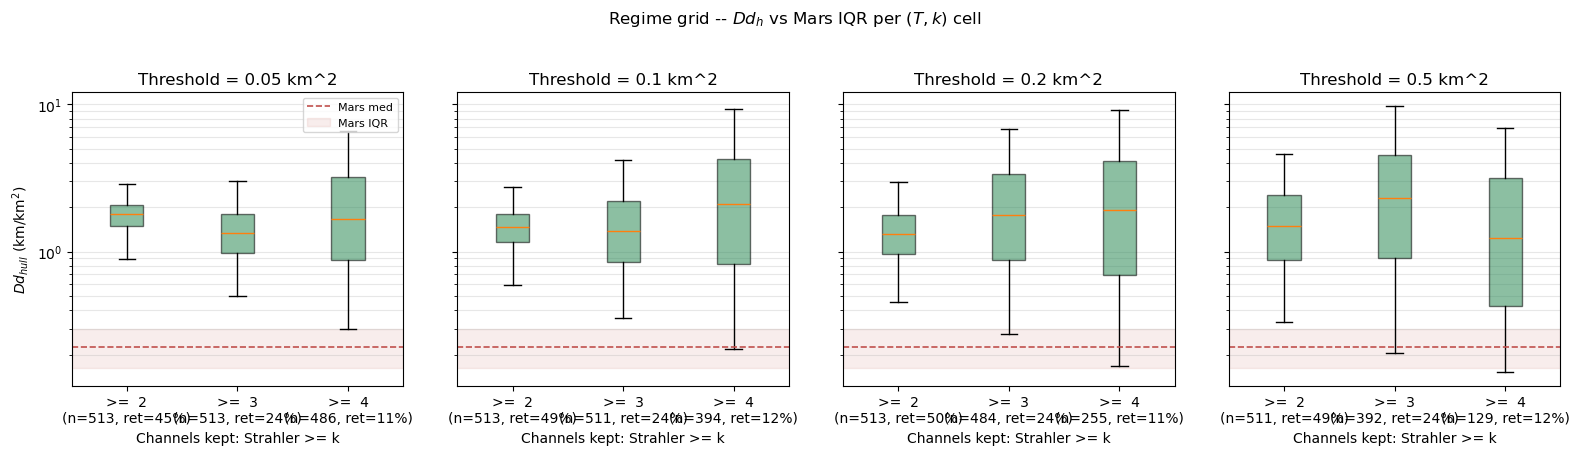

Recommended regimes (highest %-in-Mars-IQR while retaining >=30% length):


,threshold_km2,min_strahler_kept,n_outlets,median_max_strahler,median_dd_hull,median_basin_to_hull_ratio,median_pct_length_retained,pct_in_mars_iqr
0,0.0500,2,513,4,1.7870,1.2400,45.4000,0.0000
3,0.1000,2,513,3,1.4740,1.4520,48.6000,0.0000
6,0.2000,2,513,3,1.3250,1.8090,49.8000,0.0000


In [19]:
# Visualise the regime grid: Dd_hull boxplots, panel per threshold.
fig, axes = plt.subplots(1, len(REGIME_THRESHOLDS),
                          figsize=(4.0 * len(REGIME_THRESHOLDS), 4.6),
                          sharey=True)
for ax, thr in zip(np.atleast_1d(axes), REGIME_THRESHOLDS):
    box_data, labels = [], []
    grp_thr = master[np.isclose(master.threshold_km2, thr)]
    for k in REGIME_MIN_ORDERS:
        sfx = SFX_FOR_K[k]
        sub = grp_thr[grp_thr.get(f"status_{sfx}", "") == "ok"]
        box_data.append(sub[f"dd_hull_{sfx}"].dropna())
        n_o = len(sub)
        if sfx != "full":
            ret = sub[f"pct_length_{sfx}"].median() if not sub.empty else np.nan
            labels.append(f">=  {k}\n(n={n_o}, ret={ret:.0f}%)")
        else:
            labels.append(f"full\n(n={n_o})")
    ax.boxplot(box_data, tick_labels=labels, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=C_TRIM, alpha=0.55))
    ax.axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.2,
               label=f"Mars med")
    ax.axhspan(MARS_DD_Q1, MARS_DD_Q3, color=C_MARS, alpha=0.10,
               label="Mars IQR")
    ax.set_yscale("log")
    ax.set_title(f"Threshold = {thr:g} km^2")
    ax.set_xlabel("Channels kept: Strahler >= k")
    ax.grid(True, which="both", axis="y", alpha=0.3)
axes[0].set_ylabel(r"$Dd_{hull}$ (km/km$^2$)")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Regime grid -- $Dd_h$ vs Mars IQR per $(T, k)$ cell",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "fig_regime_grid_dd_hull.png", dpi=150)
plt.show()

# Recommended regimes: highest Mars-IQR overlap subject to retention >= MIN_RETAINED_PCT.
rec = regime_tbl.copy()
rec = rec[
    (rec["median_pct_length_retained"].isna())
    | (rec["median_pct_length_retained"] >= 30.0)
]
rec = rec.dropna(subset=["pct_in_mars_iqr"]).sort_values(
    "pct_in_mars_iqr", ascending=False
).head(3)
print("Recommended regimes (highest %-in-Mars-IQR while retaining >=30% length):")
display(rec[["threshold_km2", "min_strahler_kept", "n_outlets",
             "median_max_strahler", "median_dd_hull",
             "median_basin_to_hull_ratio",
             "median_pct_length_retained", "pct_in_mars_iqr"]])

## 11. Sensitivity of the optimiser to weight choices

The §8 optimiser combines three losses with weights $(w_S, w_B, w_R)$.
If small weight perturbations swing the picks dramatically, the optimiser
should be labelled *exploratory* and the regime grid (§10) treated as
the canonical answer. The sweep below tries seven weight combinations
including a "no length penalty" case.


In [20]:
WEIGHT_GRID = [
    (1.0, 1.0, 1.0),
    (2.0, 1.0, 1.0),  # complexity-heavy
    (1.0, 2.0, 1.0),  # hull/basin-heavy
    (1.0, 1.0, 2.0),  # retention-heavy
    (0.5, 1.0, 1.0),
    (1.0, 0.5, 1.0),
    (1.0, 1.0, 0.0),  # no retention guard
]

sens_rows = []
for (w_S, w_B, w_R) in WEIGHT_GRID:
    o = optimize_per_outlet(master, w_S=w_S, w_B=w_B, w_R=w_R)
    if o.empty:
        continue
    sens_rows.append(dict(
        w_S=w_S, w_B=w_B, w_R=w_R, n_outlets=len(o),
        median_threshold=o["threshold_km2"].median(),
        mode_threshold=o["threshold_km2"].mode().iloc[0],
        median_min_order=int(o["min_order"].median()),
        median_dd_hull=round(o["dd_hull"].median(), 3),
        median_basin_to_hull_ratio=round(o["basin_to_hull_area_ratio"].median(), 3),
        median_pct_length=round(o["pct_length"].median(), 1),
        median_post_strahler=int(o["post_max_strahler"].median()),
    ))
sens_tbl = pd.DataFrame(sens_rows)
display(sens_tbl)
sens_tbl.to_csv(OUT_DIR / "weight_sensitivity_summary.csv", index=False)

# Print a stability verdict.
ref = sens_tbl.iloc[0]
swings = sens_tbl[["median_threshold", "median_dd_hull",
                   "median_basin_to_hull_ratio", "median_pct_length"]].std(ddof=0)
print()
print("Stability across 7 weight combos:")
print(swings.round(3).to_frame("std across weight grid"))
if (swings["median_threshold"] > ref["median_threshold"] * 0.5
        or swings["median_dd_hull"] > ref["median_dd_hull"] * 0.5):
    print("VERDICT: optimiser is sensitive to weights -- treat as exploratory; "
          "use regime grid (sec 10) as the canonical answer.")
else:
    print("VERDICT: optimiser picks are reasonably stable across weight choices.")

,w_S,w_B,w_R,n_outlets,median_threshold,mode_threshold,median_min_order,median_dd_hull,median_basin_to_hull_ratio,median_pct_length,median_post_strahler
0,1.0000,1.0000,1.0000,509,0.1000,0.1000,2,1.8400,1.1950,52.3000,3
1,2.0000,1.0000,1.0000,509,0.1000,0.1000,2,1.6370,1.2830,51.8000,3
2,1.0000,2.0000,1.0000,509,0.0500,0.0250,2,2.3190,1.0680,53.5000,4
3,1.0000,1.0000,2.0000,509,0.1000,0.1000,2,1.8420,1.1950,52.8000,3
4,0.5000,1.0000,1.0000,509,0.0500,0.0250,2,2.3190,1.0690,55.9000,4
5,1.0000,0.5000,1.0000,509,0.1000,0.1000,2,1.6170,1.2890,52.3000,3
6,1.0000,1.0000,0.0000,509,0.0500,0.0100,2,1.7950,1.1980,41.4000,3



Stability across 7 weight combos:
                            std across weight grid
median_threshold                            0.0250
median_dd_hull                              0.2720
median_basin_to_hull_ratio                  0.0830
median_pct_length                           4.2830
VERDICT: optimiser picks are reasonably stable across weight choices.


## 12. Visual gallery: Mars next to complexity-matched Earth

**▶ EDIT** the threshold below and rerun this section to pick the regime
under inspection. For each Mars max-Strahler level (2/3/4) we pick a few
example networks; for the same level we pick Earth outlets that, after their
per-outlet trim, also land at that reranked max-Strahler.


In [24]:
# === EDITABLE PARAMETERS =============================================
GALLERY_THRESHOLD_KM2 = 1
LEVELS = (2, 3, 4)
N_EXAMPLES_PER_LEVEL = 4
# =====================================================================

# --- Mars: pick example networks per max-Strahler --------------------------
mg = mars_network_geometry()
mars_by_S = {}
for lvl in LEVELS:
    sub = ok_m[ok_m["max_strahler"] == lvl].sort_values("length_km")
    if sub.empty:
        mars_by_S[lvl] = []
        continue
    idx = np.linspace(0, len(sub) - 1, min(N_EXAMPLES_PER_LEVEL, len(sub))).astype(int)
    chosen = sub.iloc[idx]
    mars_by_S[lvl] = [(int(r.network_id), mg[int(r.network_id)], r.dd_hull,
                       r.length_km, r.hull_area_km2)
                      for _, r in chosen.iterrows()]
print({lvl: len(v) for lvl, v in mars_by_S.items()})

# --- Earth: matched outlets at GALLERY_THRESHOLD_KM2, grouped by reranked S --
g_thr = ok_m_match[np.isclose(ok_m_match.threshold_km2, GALLERY_THRESHOLD_KM2)]
earth_by_S = {}
for lvl in LEVELS:
    sub = g_thr[g_thr["matched_max_strahler"] == lvl].sort_values("matched_dd_hull")
    if sub.empty:
        earth_by_S[lvl] = []
        continue
    idx = np.linspace(0, len(sub) - 1, min(N_EXAMPLES_PER_LEVEL, len(sub))).astype(int)
    earth_by_S[lvl] = sub.iloc[idx].to_dict("records")
print({lvl: len(v) for lvl, v in earth_by_S.items()})

{2: 4, 3: 4, 4: 4}
{2: 4, 3: 4, 4: 0}


In [25]:
# Fetch Earth geometry on demand for the picked outlets.
need = {}
for lvl, recs in earth_by_S.items():
    for r in recs:
        need.setdefault(r["dem_name"], set()).add(int(r["outlet_node"]))

earth_geom = {}
for basin, outs in need.items():
    cfg = get_basin_config(LOCAL_TO_PAPER_BASIN.get(basin, basin))
    recs = collect_dd_hull_trim_for_dem(
        dem_path=EXAMPLE_DEMS[basin], basin_name=basin,
        threshold_km2=GALLERY_THRESHOLD_KM2,
        z_th=cfg["z_th"], lat_deg=cfg["lat"],
        min_outlet_basin_pixels=MIN_BASIN_PX,
        max_outlets=MAX_OUTLETS,
        geometry_for_outlets=outs,
    )
    for r in recs:
        if int(r["outlet_node"]) in outs:
            earth_geom[(basin, int(r["outlet_node"]))] = r

print(f"fetched geometry for {len(earth_geom)} Earth outlets")

fetched geometry for 8 Earth outlets


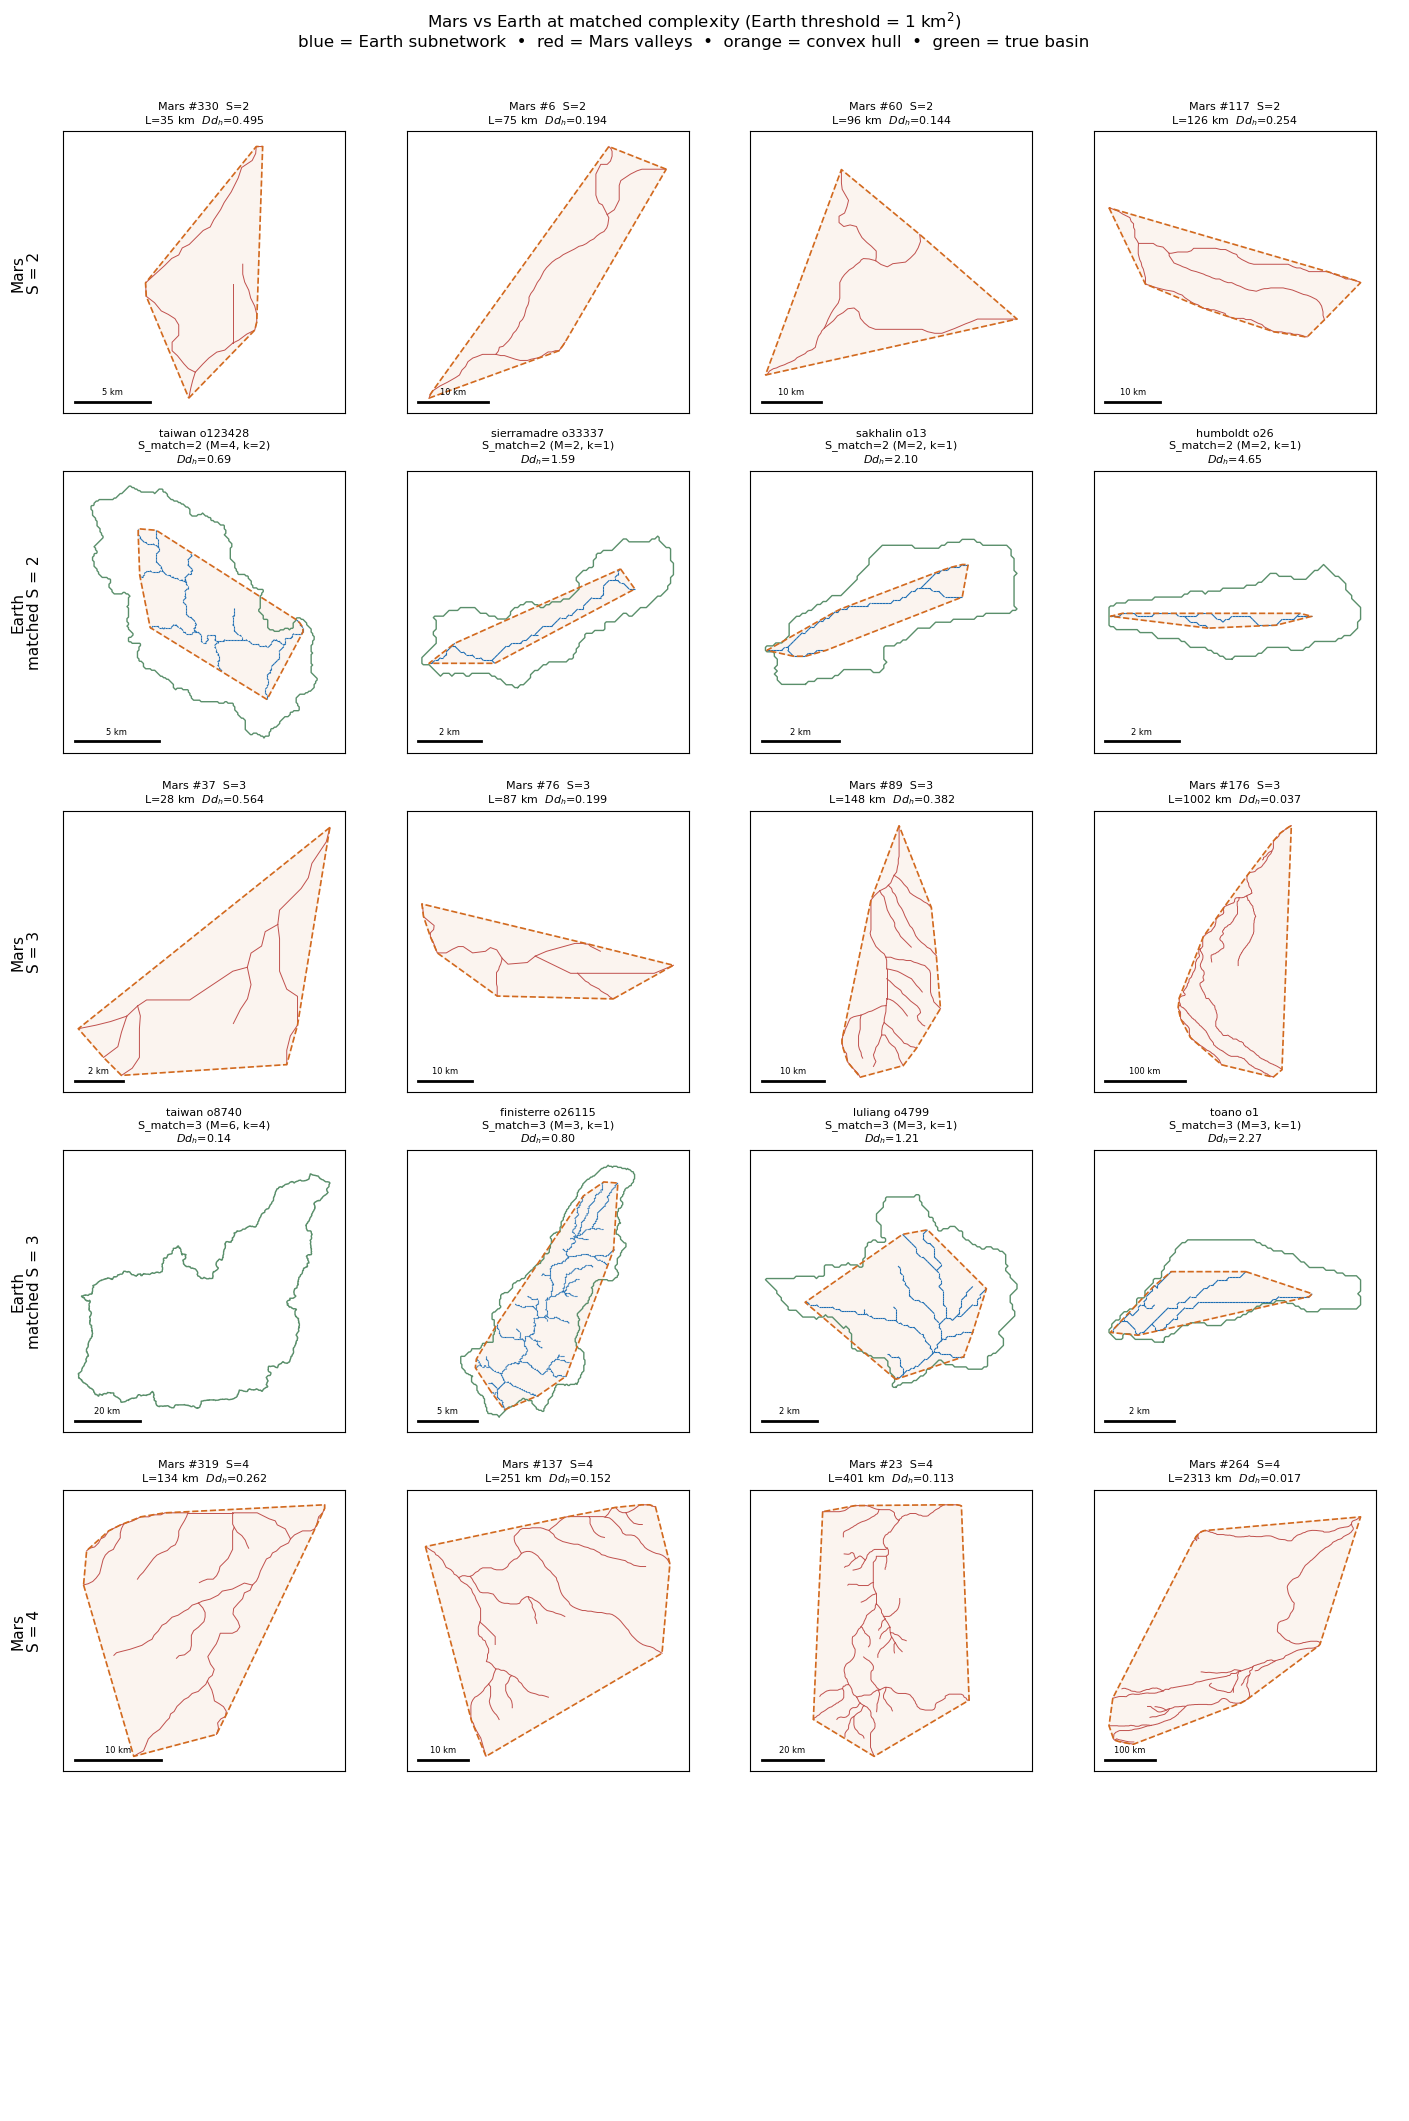

In [26]:
# 2-row grid per Strahler level: row 0 = Mars, row 1 = Earth-matched.
n_rows = 2 * len(LEVELS)
n_cols = N_EXAMPLES_PER_LEVEL
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 3.6 * n_rows))

# Helper to pick the matched-variant suffix for plotting (e.g. "trim", "ge3"...).
for i, lvl in enumerate(LEVELS):
    # Mars row
    for j, ax in enumerate(axes[2 * i]):
        if j >= len(mars_by_S[lvl]):
            ax.axis("off"); continue
        nid, g, dd, L, A = mars_by_S[lvl][j]
        draw_panel(ax, lines=g["lines"], hull_xy=g["hull_xy"],
                   title=f"Mars #{nid}  S={lvl}\n"
                         f"L={L:.0f} km  $Dd_h$={dd:.3f}")
    axes[2 * i, 0].set_ylabel(f"Mars\nS = {lvl}",
                              fontsize=11, rotation=90, labelpad=15)

    # Earth row
    for j, ax in enumerate(axes[2 * i + 1]):
        if j >= len(earth_by_S[lvl]):
            ax.axis("off"); continue
        r = earth_by_S[lvl][j]
        g = earth_geom.get((r["dem_name"], int(r["outlet_node"])))
        if g is None:
            ax.axis("off"); continue
        sfx = r["matched_variant"]
        segs = g.get(f"stream_seg_{sfx}")
        hull = g.get(f"hull_xy_{sfx}")
        draw_panel(ax, segs=segs, hull_xy=hull,
                   boundary_xy=g.get("basin_boundary_xy"),
                   title=f"{r['dem_name']} o{int(r['outlet_node'])}\n"
                         f"S_match={lvl} (M={int(r['full_max_strahler'])}, k={int(r['applied_min_order'])})\n"
                         f"$Dd_h$={r['matched_dd_hull']:.2f}")
    axes[2 * i + 1, 0].set_ylabel(f"Earth\nmatched S = {lvl}",
                                   fontsize=11, rotation=90, labelpad=15)

fig.suptitle(f"Mars vs Earth at matched complexity "
             f"(Earth threshold = {GALLERY_THRESHOLD_KM2:g} km$^2$)\n"
             f"blue = Earth subnetwork  •  red = Mars valleys  •  orange = convex hull  •  green = true basin",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / "fig_mars_vs_earth_at_matched_complexity.png", dpi=140)
plt.show()

## 13. Takeaways

1. **Mars valley networks are simple in Strahler terms.** 86 % of the 391
   mapped networks have max-Strahler exactly 3; only 2 reach 5.

2. **Earth basins are intrinsically more complex** at every threshold in
   our sweep; below ~1 km^2 the median Earth outlet sits at S = 4-5.

3. **Calibration vs evaluation matters.** Optimising Earth `Dd_hull`
   directly toward Mars `Dd_hull` is circular -- it forces the comparison
   metric onto the result. Sections 8-9 now split the workflow:
   calibration losses (complexity, basin-to-hull fit, length retention)
   drive the picks; `Dd_hull` is reported as an evaluation outcome only.

4. **Pruning maps (sec 7) make the trim visible.** They reproduce the
   picture from the earlier practical-thresholds notebook: at low
   thresholds removing 1st-order links collapses a dense mesh into a
   still-branched skeleton; removing 1st+2nd leaves a Mars-like trunk.

5. **Area-bin grouping is unsafe** at `AREA_BIN_KM2 = 0.1` for this
   dataset: ~6% of (DEM, area_bin, threshold) groups merge two distinct
   outlets. The notebook now backfills outlet coordinates via
   `augment_sweep_with_outlet_coords` and groups by coordinate cluster
   (`match_outlets_by_coords`). When coords are missing the validator
   surfaces a warning and the optimiser falls back transparently.

6. **`basin_to_hull_area_ratio = Dd_hull/Dd_true = A_basin/A_hull`**.
   1 means the convex hull tracks the true catchment. This is the
   geometric representativeness target; pursuing it is *not* circular
   the way pursuing `Dd_hull` is.

7. **Regime grid (sec 10) is the defensible scientific report.**
   For each (threshold, min-Strahler-kept) cell we tabulate surviving
   outlets, complexity, `Dd_hull`/`Dd_true`, basin/hull ratio, retention,
   and Mars-IQR overlap. The notebook prints the top 3 regimes by
   Mars-IQR overlap subject to >=30% length retention -- the recommended
   talking points for Liran.

8. **The optimiser's stability is reported (sec 11).** If small weight
   changes swing picks dramatically the optimiser is exploratory and
   should not be the headline result.

9. **Remaining gap is structural.** Even after calibration, Mars trunks
   bend and meander within their hulls more loosely than Earth dendritic
   trunks. The residual `Dd_hull` gap is genuinely about geometry, not a
   knob we should have tuned harder.

*Outputs (CSV + PNG) are written to* `data/results/drainage_density_calibration/complexity_calibration/`.
